In [42]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay

In [43]:
df = pd.read_excel('Telco_customer_churn.xlsx')

In [44]:
# Removing the columns which are either not important in predicting the output or cause leakage
df.drop(columns = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Longitude', 'Latitude', 'Churn Reason', 'CLTV', 'Churn Score', 'Churn Label'], inplace = True)

In [45]:
df.sample(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2713,Male,No,No,Yes,6,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,98.35,0
3086,Male,No,Yes,No,58,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.75,1185.95,0
4109,Male,No,No,No,17,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.45,369.05,0
3158,Female,No,Yes,No,54,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.05,1102.4,0
3375,Female,No,Yes,No,71,No,No phone service,DSL,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),47.60,3377.8,0


In [46]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [48]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [50]:
# Total Charges column has 13 missing values which is approximately 0.2% of whole data which is not a big proportion so that we can drop those rows.
df.dropna(inplace = True)

In [51]:
X = df.drop(columns = ['Churn Value'])
y = df['Churn Value']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [53]:
df.nunique()

Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          72
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1584
Total Charges        6530
Churn Value             2
dtype: int64

In [54]:
X_train.sample(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
1322,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Mailed check,79.65,152.70
3705,Female,No,Yes,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.00,89.75
2308,Male,No,No,No,52,Yes,No,DSL,Yes,Yes,No,No,Yes,No,Two year,Yes,Credit card (automatic),63.25,3342.45
1704,Male,No,No,No,2,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,95.65,167.30
499,Male,No,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,94.45,5124.60


In [55]:
# Encoding Gender Column
# X_train['Gender'] = X_train['Gender'].map({'Male':1, 'Female':0})
# X_test['Gender'] = X_test['Gender'].map({'Male':1, 'Female':0})

In [56]:
# binary_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Paperless Billing', 'Phone Service']

In [57]:
# Encoding Binary Columns (Yes/ No)
# for col in binary_cols:
#     X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
#     X_test[col] = X_test[col].map({'Yes': 1, 'No': 0})

In [58]:
X_train.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
6030,Male,No,Yes,No,24,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.00,2248.05
3409,Female,No,Yes,No,40,Yes,Yes,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),78.85,3126.85
5482,Male,No,Yes,No,4,Yes,Yes,DSL,No,No,Yes,No,Yes,No,Month-to-month,No,Electronic check,65.60,250.10
5523,Female,No,No,No,4,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),55.50,227.35
6337,Female,No,Yes,Yes,64,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,24.90,1595.50


In [59]:
# Ordinal and OneHotEncoding
transformer = ColumnTransformer(transformers = [
    ('ordinalencoder', OrdinalEncoder(categories = [['Month-to-month', 'One year', 'Two year']]), ['Contract']),
    ('onehotencoder', OneHotEncoder(drop = 'first', sparse_output = False), ['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
                                                                              'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
                                                                                'Payment Method','Senior Citizen', 'Partner', 'Dependents', 'Paperless Billing',
                                                                                  'Phone Service', 'Gender']),
    ('standardscaler', StandardScaler(),['Tenure Months', 'Monthly Charges', 'Total Charges'])
], remainder = 'passthrough', force_int_remainder_cols=False)

In [60]:
X_train_trf = transformer.fit_transform(X_train)
X_test_trf = transformer.transform(X_test)

## Baseline Model

In [62]:
# Training Logistic Regression as our Baseline Model
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X_train_trf, y_train)

LogisticRegression()

In [63]:
y_pred = lor.predict(X_test_trf)

In [64]:
def model_metrics(model, X_test, y_test, roc = False):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    vals = [
        ['Accuracy', acc], 
        ['Precision', precision], 
        ['Recall', recall], 
        ['F1', f1]
           ]
    if roc == True:
        roc_auc = roc_auc_score(y_test,  model.predict_proba(X_test)[:,1])
        vals.append(['ROC', roc_auc])
        
    df = pd.DataFrame(vals, columns = ['Metric', 'Score'])
    df['Score'] = np.round(df['Score'], 4)
    
    return df

In [65]:
print('Logistic Regression Performance')
lorm = model_metrics(lor, X_test_trf, y_test, roc = True)
lorm

Logistic Regression Performance


,Metric,Score
0,Accuracy,0.8145
1,Precision,0.7030
2,Recall,0.5873
3,F1,0.6400
4,ROC,0.8624


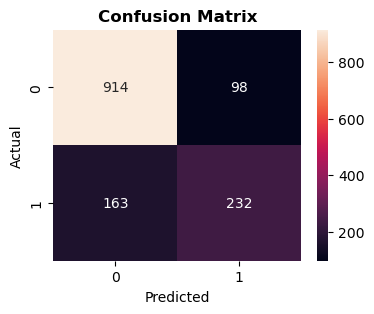

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion Matrix", fontweight = 'bold' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Key Insights:
* Logistic Regression was used as the baseline model for customer churn prediction.
* The model achieved an accuracy of 81.44%, indicating good overall performance.
* However, the model correctly identified only 232 out of 395 actual churners, while 163 churning customers were missed. This is reflected in the Recall score of 58.73%.
* Since failing to identify actual churners can result in customer and revenue loss, improving the Recall score will be an important objective when evaluating more advanced models.

In [68]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(splitter = 'random', min_samples_split = 40, max_depth = 5, min_samples_leaf = 200, max_leaf_nodes = 10)
dt.fit(X_train_trf, y_train.values.ravel())

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=10, min_samples_leaf=200,
                       min_samples_split=40, splitter='random')

In [69]:
dtm = model_metrics(dt, X_test_trf, y_test, roc = True)
dtm

,Metric,Score
0,Accuracy,0.7918
1,Precision,0.6962
2,Recall,0.4582
3,F1,0.5527
4,ROC,0.8318


In [70]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train_trf, y_train)

RandomForestClassifier()

In [71]:
rfm = model_metrics(rf, X_test_trf, y_test)
rfm

,Metric,Score
0,Accuracy,0.7939
1,Precision,0.6699
2,Recall,0.5241
3,F1,0.5881


In [72]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_trf, y_train)

SVC()

In [73]:
# svmm = model_metrics(svc, X_test_trf, y_test)
# svmm

In [74]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train_trf, y_train)

GradientBoostingClassifier()

In [75]:
gbcm = model_metrics(gbc, X_test_trf, y_test)
gbcm

,Metric,Score
0,Accuracy,0.8124
1,Precision,0.7066
2,Recall,0.5671
3,F1,0.6292


In [76]:
from xgboost import XGBClassifier
xgbc = XGBClassifier()
xgbc.fit(X_train_trf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [77]:
xgbcm = model_metrics(xgbc, X_test_trf, y_test)
xgbcm

,Metric,Score
0,Accuracy,0.7882
1,Precision,0.6439
2,Recall,0.5494
3,F1,0.5929


In [78]:
pd.concat(
    {
        'Metric': pd.Series(['Accuracy', 'Precision', 'Recall', 'F1']),
        'lor': lorm['Score'],
        'dt': dtm['Score'],
        'rf': rfm['Score'],
        'gbc': gbcm['Score'],
        'xgbc': xgbcm['Score']
    },
    axis = 1
)

,Metric,lor,dt,rf,gbc,xgbc
0,Accuracy,0.8145,0.7918,0.7939,0.8124,0.7882
1,Precision,0.7030,0.6962,0.6699,0.7066,0.6439
2,Recall,0.5873,0.4582,0.5241,0.5671,0.5494
3,F1,0.6400,0.5527,0.5881,0.6292,0.5929
4,NaN,0.8624,0.8318,NaN,NaN,NaN


Since Logistic Regression is performing better than any other model although it was considered as baseline model we need to tune the hyperparameters of each model to check which one gives best results for our data.

In [79]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Logistic Regression Hyperparameter Tuning

In [80]:
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [500, 1000, 2000]
}

log_reg_rscv = RandomizedSearchCV(
    estimator = LogisticRegression(),
    param_distributions = param_dist,
    n_jobs = -1,
    verbose = 2,
    cv = 20)

In [81]:
log_reg_rscv.fit(X_train_trf, y_train)

Fitting 20 folds for each of 10 candidates, totalling 200 fits


RandomizedSearchCV(cv=20, estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100,
                                              1000],
                                        'class_weight': [None, 'balanced'],
                                        'max_iter': [500, 1000, 2000],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   verbose=2)

In [82]:
logreg = LogisticRegression(C=1, max_iter=1000, solver='saga')
logreg.fit(X_train_trf, y_train)

LogisticRegression(C=1, max_iter=1000, solver='saga')

In [83]:
lor_metrics = model_metrics(logreg, X_test_trf, y_test)
lor_metrics

,Metric,Score
0,Accuracy,0.8124
1,Precision,0.7003
2,Recall,0.5797
3,F1,0.6343


### Random Forest Hyperparameter tuning

In [84]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
rsc_rf = RandomizedSearchCV(
    estimator = RandomForestClassifier(),
    param_distributions = param_grid,
    n_jobs = -1,
    verbose = 2,
    cv = 5)

In [85]:
rsc_rf.fit(X_train_trf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 10, 15, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=2)

In [86]:
rf2 = RandomForestClassifier(min_samples_leaf=4, min_samples_split=5, n_estimators=300)
rf2.fit(X_train_trf, y_train)

RandomForestClassifier(min_samples_leaf=4, min_samples_split=5,
                       n_estimators=300)

In [87]:
rf_metrics = model_metrics(rf2, X_test_trf, y_test)
rf_metrics

,Metric,Score
0,Accuracy,0.8060
1,Precision,0.7007
2,Recall,0.5392
3,F1,0.6094


### XGBoost Hyperparameters Tuning

In [88]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}

rsc_xgbc = RandomizedSearchCV(
    estimator = XGBClassifier(),
    param_distributions = param_dist,
    n_jobs = -1,
    verbose = 2,
    cv = 5
)

In [89]:
rsc_xgbc.fit(X_train_trf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 2, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   verbose=2)

In [90]:
xgbc2 = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=5, min_child_weight=1, colsample_bytree=0.8, gamma=0.1)
xgbc2.fit(X_train_trf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [91]:
xgbc_metrics = model_metrics(xgbc2, X_test_trf, y_test)
xgbc_metrics

,Metric,Score
0,Accuracy,0.8074
1,Precision,0.6950
2,Recall,0.5595
3,F1,0.6199


### Gradient Boosting Classifier Hyperparameter Tuning

In [92]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

rsc_gbc = RandomizedSearchCV(
    estimator = GradientBoostingClassifier(),
    param_distributions = param_dist,
    n_jobs = -1,
    verbose = 2,
    cv = 5
)

In [93]:
rsc_gbc.fit(X_train_trf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [50, 100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   verbose=2)

In [94]:
gbc2 = GradientBoostingClassifier(max_depth=2, min_samples_leaf = 2, max_features='log2',min_samples_split=10, n_estimators=200,subsample=0.8)
gbc2.fit(X_train_trf, y_train)

GradientBoostingClassifier(max_depth=2, max_features='log2', min_samples_leaf=2,
                           min_samples_split=10, n_estimators=200,
                           subsample=0.8)

In [95]:
gbc_metrics = model_metrics(gbc2, X_test_trf, y_test)
gbc_metrics

,Metric,Score
0,Accuracy,0.8138
1,Precision,0.7046
2,Recall,0.5797
3,F1,0.6361


### Final Model Comparision After Hyperparameter Tuning

In [96]:
pd.concat(
    {
        'Metric': pd.Series(['Accuracy', 'Precision', 'Recall', 'F1']),
        'lor': lor_metrics['Score'],
        'rf': rf_metrics['Score'],
        'gbc': gbc_metrics['Score'],
        'xgbc': xgbc_metrics['Score']
    },
    axis = 1
)

,Metric,lor,rf,gbc,xgbc
0,Accuracy,0.8124,0.8060,0.8138,0.8074
1,Precision,0.7003,0.7007,0.7046,0.6950
2,Recall,0.5797,0.5392,0.5797,0.5595
3,F1,0.6343,0.6094,0.6361,0.6199


### Key Insights:
- Logistic Regression and Gradient Boosting achieved highest accuracy of (81.24%) among all the models we've tested.
- Logistic Regression achieved the highest F1-score (63.43%), indicating the best overall balance between Precision and Recall.
- Since customer churn prediction focuses on identifying customers who are likely to leave, Recall was considered an important metric because it helps reduce Type II errors (False Negatives), which can lead to customer and revenue loss.
- Logistic Regression performed best comparing to other complex ensemble models while being easier to interpret and explain.
- Therefore, Logistic Regression was selected as the final model for this project due to its strong performance, simplicity, and business interpretability.

In [140]:
lr = LogisticRegression(C=1, max_iter=1000, solver='saga')
lr.fit(X_train_trf, y_train)

LogisticRegression(C=1, max_iter=1000, solver='saga')

In [141]:
y_pred = lr.predict(X_test_trf)
model_metrics(lr, X_test_trf, y_test)

,Metric,Score
0,Accuracy,0.8124
1,Precision,0.7003
2,Recall,0.5797
3,F1,0.6343


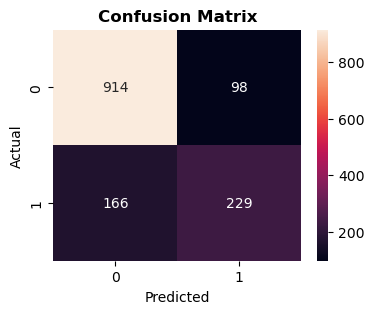

In [142]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion Matrix", fontweight = 'bold' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [143]:
# Tuning decision threshold to reduce Type-2 error and increase Recall score.
y_prob = lr.predict_proba(X_test_trf)[:,1]
y_pred = (y_prob >= 0.4).astype(int)

In [144]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

accuracy: 0.7953091684434968
recall: 0.6810126582278481
F1 score: 0.6513317191283293


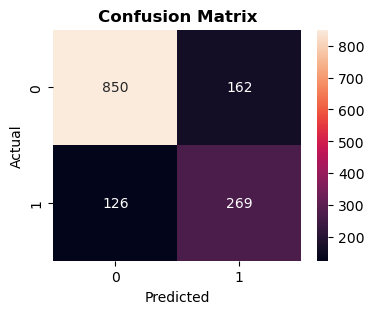

In [138]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title("Confusion Matrix", fontweight = 'bold' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [146]:
best_threshold = 0.35

### Threshold Tuning for Reducing Type II Error

The default threshold of 0.5 resulted in a recall of 57.97%, indicating that many churn customers were missed (high Type II error).

To improve the identification of churn customers, different classification thresholds were tested. After evaluation, a threshold of 0.35 was selected as it provided a better balance between recall and precision.

- Recall increased from **57.97%** to **72.66%**
- False negatives decreased from **166** to **108**
- Accuracy remained reasonably high at **78.61%**

Since the business objective is to identify potential churn customers, reducing Type II error was prioritized over maximizing accuracy.

In [147]:
import pickle
pickle.dump(lr, open('model.pkl', 'wb'))
pickle.dump(transformer, open('preprocessor.pkl', 'wb'))
with open('threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

In [98]:
feature_names = transformer.get_feature_names_out()

In [99]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
})

In [100]:
coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
28,standardscaler__Total Charges,0.725841
3,onehotencoder__Internet Service_Fiber optic,0.522514
23,onehotencoder__Paperless Billing_Yes,0.401929
21,onehotencoder__Partner_Yes,0.308176
1,onehotencoder__Multiple Lines_No phone service,0.293886
18,onehotencoder__Payment Method_Electronic check,0.266292
2,onehotencoder__Multiple Lines_Yes,0.198835
27,standardscaler__Monthly Charges,0.151027
16,onehotencoder__Streaming Movies_Yes,0.137413
20,onehotencoder__Senior Citizen_Yes,0.130872


#### Key Findings from Logistic Regression:
* Customers with longer tenure were significantly less likely to churn.
* Customers with one-year and two-year contracts showed lower churn rates compared to month-to-month customers.
* Customers subscribed to online security and tech support services were less likely to leave the company.
* Customers using fiber optic internet and electronic check payment methods showed a higher tendency to churn.
* These insights can help the company identify high-risk customers and design targeted retention strategies.